In [71]:
 import pandas as pd
 import numpy as np
 import matplotlib.pyplot as plt
 import seaborn as sns
 from sklearn.model_selection import train_test_split
 from sklearn.preprocessing import LabelEncoder,StandardScaler
 from sklearn.linear_model import LinearRegression
 from sklearn.metrics import mean_squared_error, r2_score

In [52]:
sales=pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset.csv")
print(sales.head())
print(sales.info())
print(sales.describe())


  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  South   2355      0.26  918.45  Tamil Nadu  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         ------

## Data preprocessing



In [37]:
print("Missing values before handling:")
print(sales.isnull().sum())

sales['Order Date'] = pd.to_datetime(sales['Order Date'], format='mixed', dayfirst=True)

categorical_cols = ['Category', 'Sub Category', 'City', 'Region', 'State']
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    sales[col] = label_encoders[col].fit_transform(sales[col])

print("\nData types after conversion and encoding:")
print(sales.info())

Missing values before handling:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Data types after conversion and encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Customer Name  9994 non-null   object        
 2   Category       9994 non-null   int64         
 3   Sub Category   9994 non-null   int64         
 4   City           9994 non-null   int64         
 5   Order Date     9994 non-null   datetime64[ns]
 6   Region         9994 non-null   int64         
 7   Sales          9994 non-null   int64         
 8   Discount       9994 non-null   float64       
 9   Profit         9994 non-null  

In [74]:
categorical_cols = ['Category', 'Sub Category', 'City', 'Region', 'State']
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    sales[col] = label_encoders[col].fit_transform(sales[col])

features = ['Category', 'Sub Category', 'City', 'Region', 'Discount']
target = 'Sales'

X = sales[features]
y = sales[target]

# Verify dtypes before splitting and training
print("Data types of features (X) after re-encoding:")
print(X.dtypes)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nFeatures (X) shape after removing 'Sales' and 'Profit':", X.shape)
print("Target (y) shape:", y.shape)

Data types of features (X) after re-encoding:
Category          int64
Sub Category      int64
City              int64
Region            int64
Discount        float64
dtype: object

Features (X) shape after removing 'Sales' and 'Profit': (9994, 5)
Target (y) shape: (9994,)


## Exploratory data analysis (EDA)


Descriptive statistics of Sales by Category:
                 mean  median         std
Category                                 
0         1494.891012  1501.0  580.833734
1         1489.509286  1512.0  585.201624
2         1521.745638  1522.0  572.847848
3         1513.070100  1541.5  569.730711
4         1481.471791  1450.0  574.527240
5         1497.753123  1495.0  585.119233
6         1477.903567  1460.0  575.020672


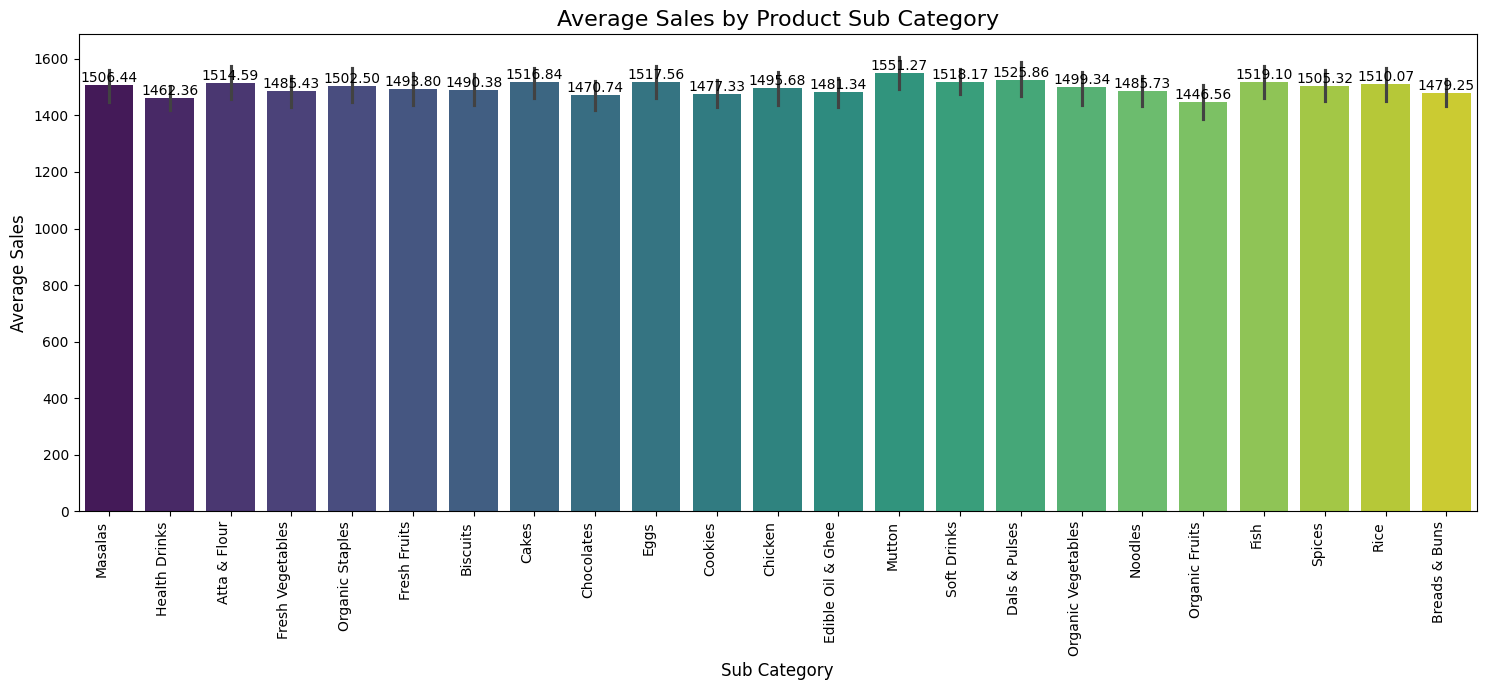


Top 10 Cities by Total Sales:
City
6     706764
21    676550
0     667177
19    659812
13    659738
16    657093
14    653179
17    643652
7     642273
8     637273
Name: Sales, dtype: int64


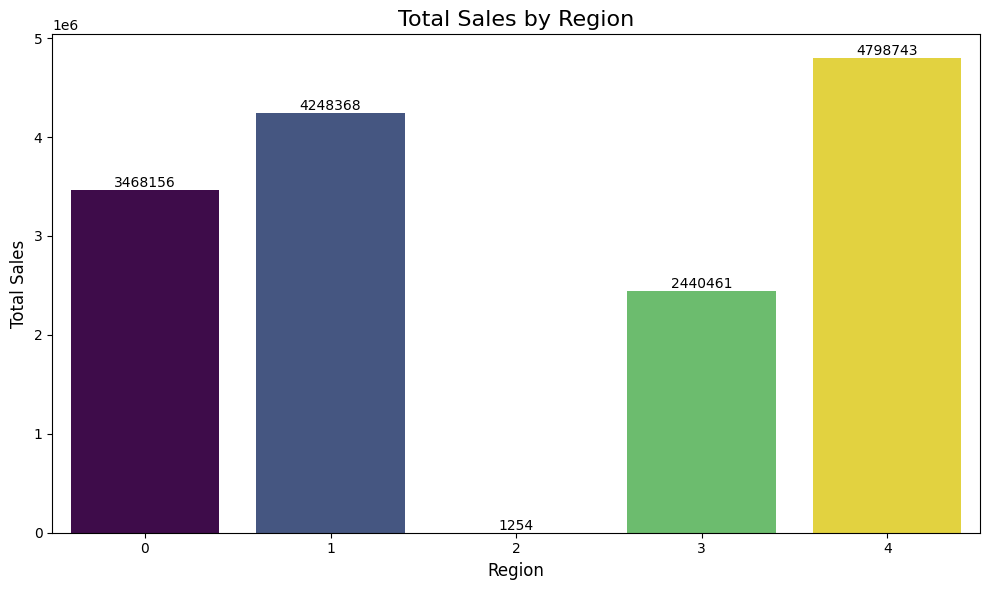

In [65]:
print("Descriptive statistics of Sales by Category:")
print(sales.groupby('Category')['Sales'].agg(['mean', 'median', 'std']))

plt.figure(figsize=(15, 7))
# Use inverse_transform to get original sub-category names for plotting
sales['Original Sub Category'] = label_encoders['Sub Category'].inverse_transform(sales['Sub Category'])
ax_sub = sns.barplot(x='Original Sub Category', y='Sales', data=sales, palette='viridis', hue='Original Sub Category', legend=False)
plt.title('Average Sales by Product Sub Category', fontsize=16)
plt.xlabel('Sub Category', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.xticks(rotation=90, ha='right')
for container in ax_sub.containers:
    ax_sub.bar_label(container, fmt='%.2f')
plt.tight_layout()
plt.show()

print("\nTop 10 Cities by Total Sales:")
city_sales = sales.groupby('City')['Sales'].sum().sort_values(ascending=False)
print(city_sales.head(10))

plt.figure(figsize=(10, 6))
ax_region = sns.barplot(x='Region', y='Sales', data=sales.groupby('Region')['Sales'].sum().reset_index(), palette='viridis', hue='Region', legend=False)
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
for container in ax_region.containers:
    ax_region.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

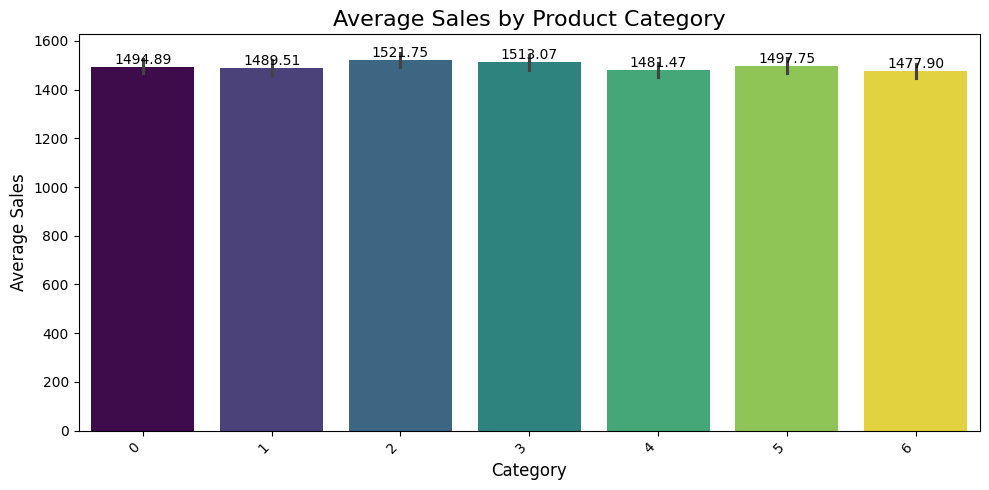

In [42]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Category', y='Sales', data=sales, palette='viridis', hue='Category', legend=False)
plt.title('Average Sales by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add exact sales values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

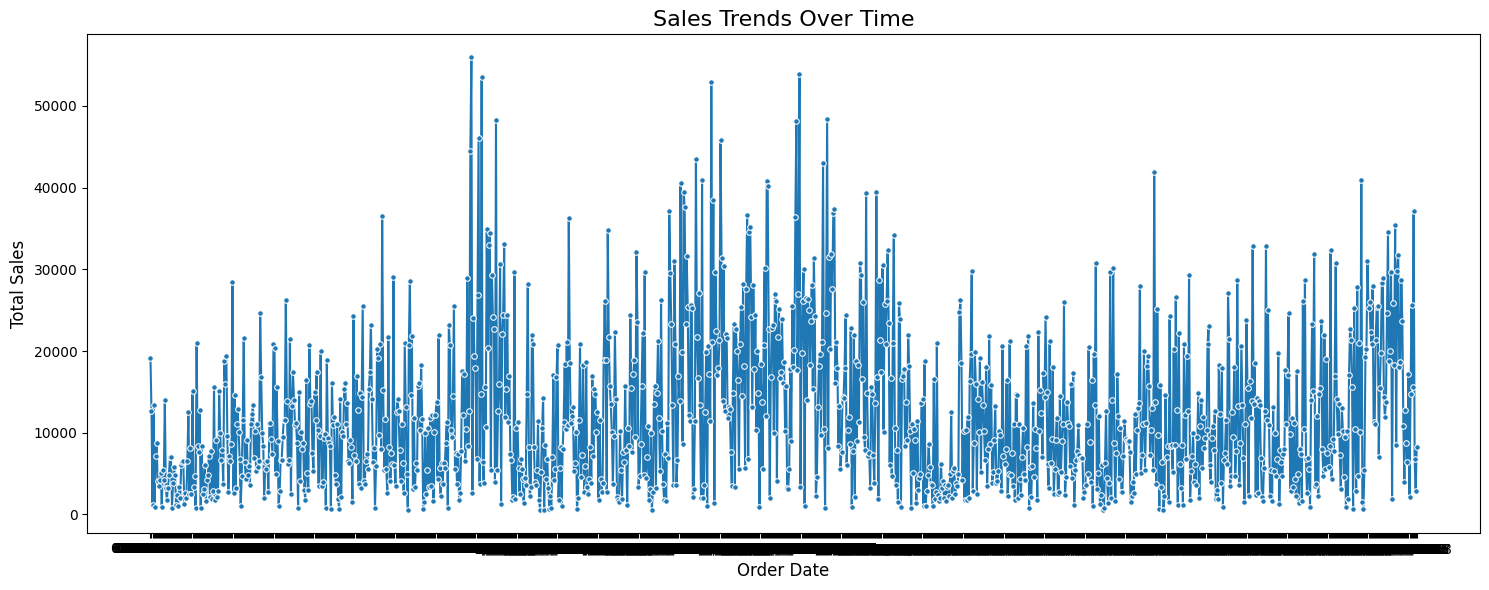

In [53]:
sales_over_time = sales.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(x='Order Date', y='Sales', data=sales_over_time, marker='o', markersize=4)
plt.title('Sales Trends Over Time', fontsize=16)
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.tight_layout()
plt.show()

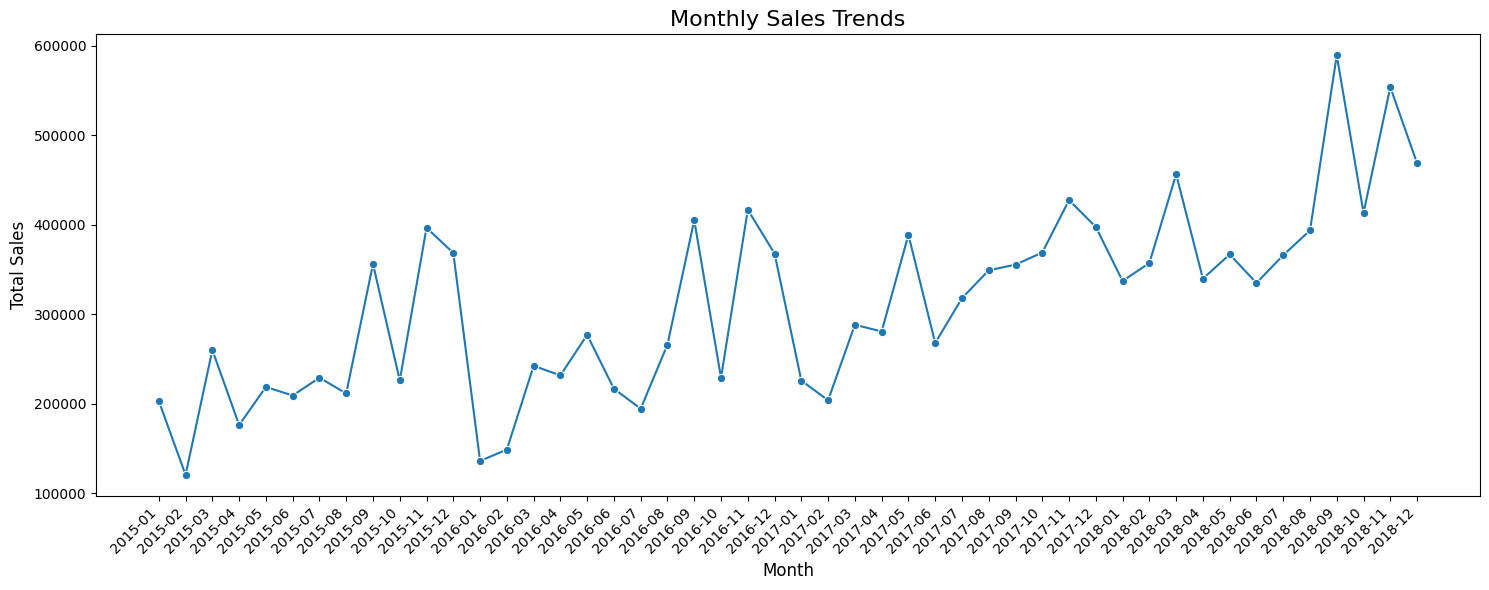

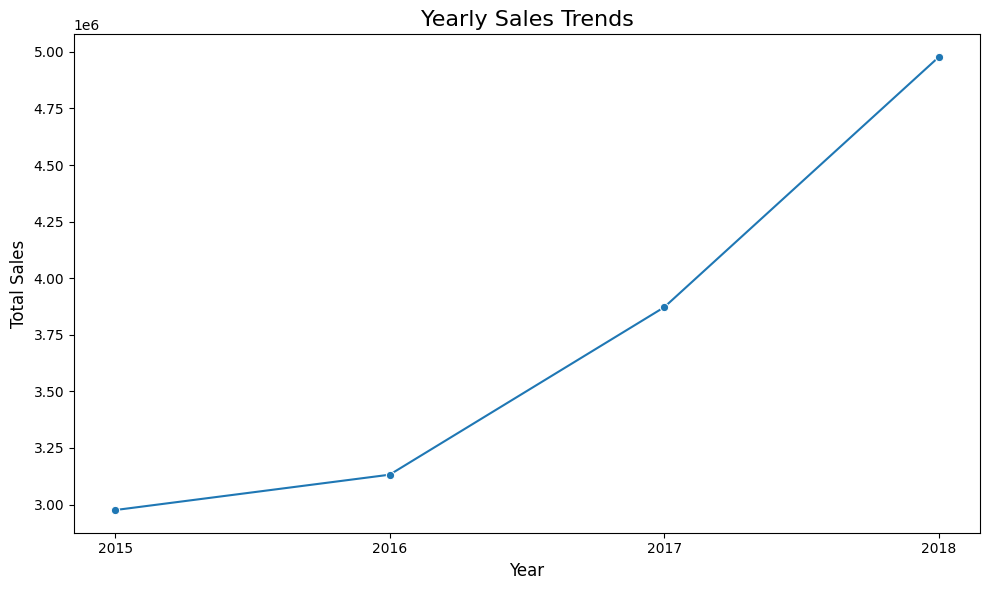


Most sold product sub-categories:
   Sub Category    Sales
0            13  1051439
1            21  1033874
2             6   768213
3             2   742586
4            16   735435


In [81]:
# Ensure 'Order Date' is in datetime format
sales['Order Date'] = pd.to_datetime(sales['Order Date'], format='mixed', dayfirst=True)

# Analyze monthly sales trends
sales['Order Month'] = sales['Order Date'].dt.to_period('M')
monthly_sales = sales.groupby('Order Month')['Sales'].sum().reset_index()
monthly_sales['Order Month'] = monthly_sales['Order Month'].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(x='Order Month', y='Sales', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trends', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analyze yearly sales trends
sales['Order Year'] = sales['Order Date'].dt.to_period('Y')
yearly_sales = sales.groupby('Order Year')['Sales'].sum().reset_index()
yearly_sales['Order Year'] = yearly_sales['Order Year'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(x='Order Year', y='Sales', data=yearly_sales, marker='o')
plt.title('Yearly Sales Trends', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.tight_layout()
plt.show()


# Identify the most sold product sub-category
sub_category_sales = sales.groupby('Sub Category')['Sales'].sum().sort_values(ascending=False).reset_index()

# Use the label encoder to get the original sub-category names
sub_category_sales['Sub Category'] = label_encoders['Sub Category'].inverse_transform(sub_category_sales['Sub Category'])

print("\nMost sold product sub-categories:")
print(sub_category_sales.head())

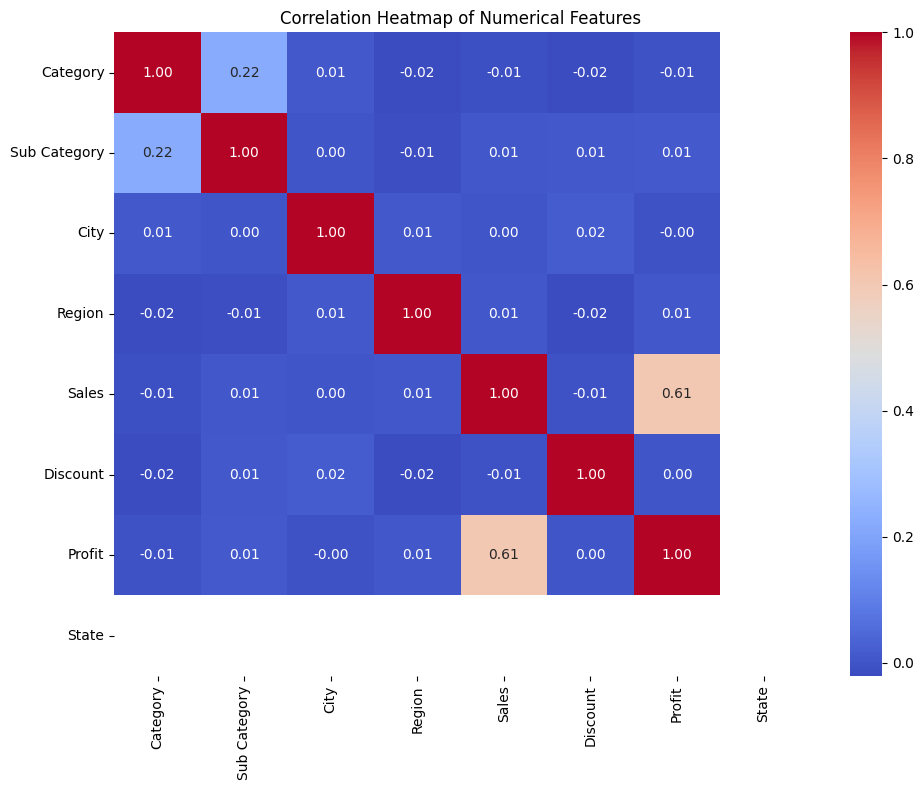

In [27]:
numerical_cols = sales.select_dtypes(include=np.number).columns
correlation_matrix = sales[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

Sales performance by Region:
            sum         mean  median         std
Region                                          
0       3468156  1492.964270  1486.0  575.764718
1       4248368  1491.702247  1500.0  574.266909
2          1254  1254.000000  1254.0         NaN
3       2440461  1507.387894  1517.0  581.315656
4       4798743  1498.202623  1500.0  580.131737


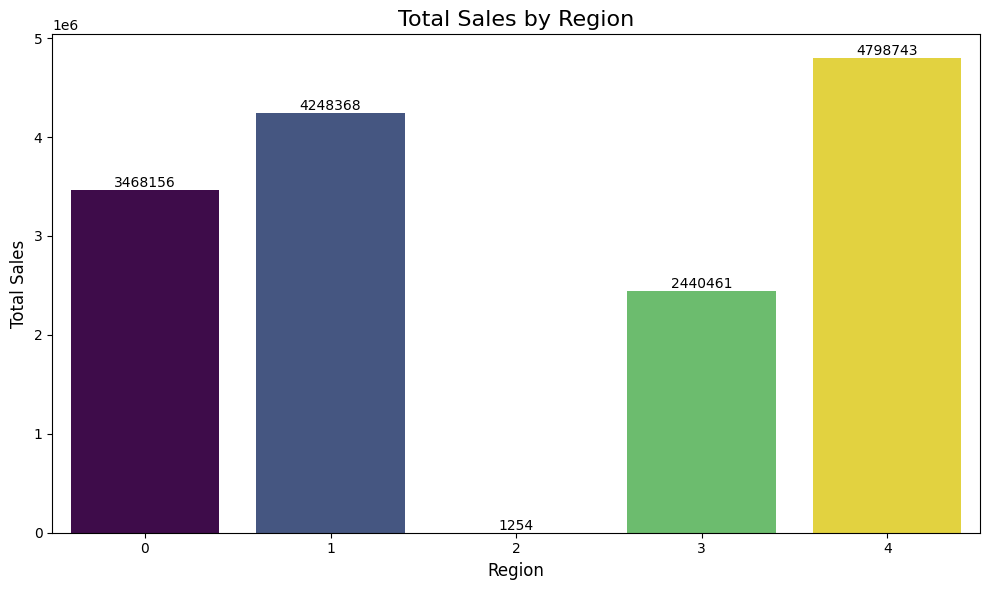


Sales performance by City (Top 10 by Total Sales):
         sum         mean  median         std
City                                         
6     706764  1539.790850  1564.0  583.753185
21    676550  1555.287356  1559.0  572.451401
0     667177  1509.450226  1546.0  569.646175
19    659812  1479.399103  1471.5  571.572550
13    659738  1520.133641  1567.0  570.170017
16    657093  1524.577726  1537.0  562.862231
14    653179  1519.020930  1527.5  570.738774
17    643652  1489.935185  1487.0  591.005722
7     642273  1493.658140  1512.5  558.321687
8     637273  1448.347727  1407.5  591.165872


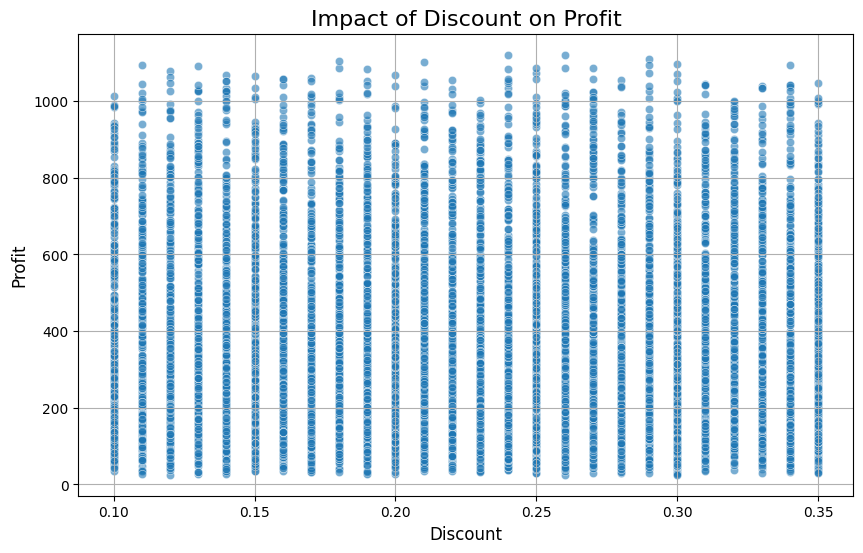

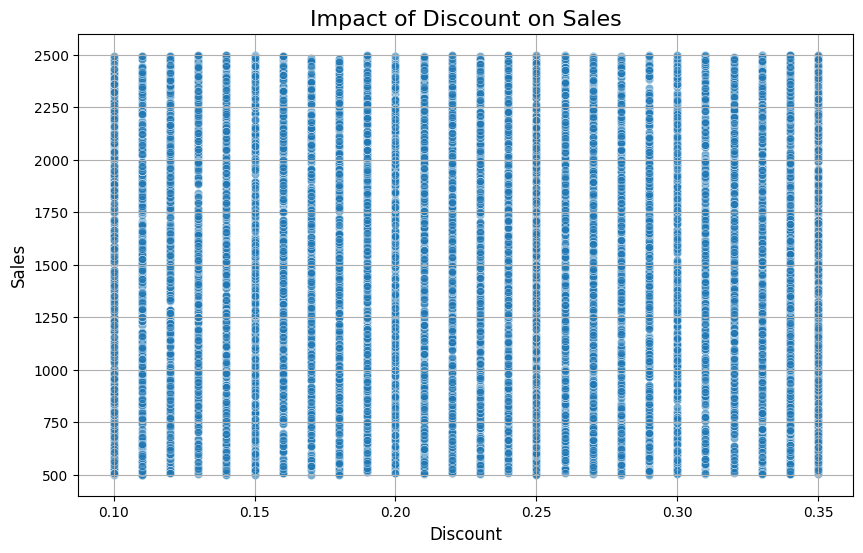


Sales and Profit trends by Category:
            Sales                          Profit                    
              sum         mean  median        sum        mean  median
Category                                                             
0         2112281  1494.891012  1501.0  528521.06  374.041798  313.28
1         2085313  1489.509286  1512.0  525605.76  375.432686  326.63
2         2267401  1521.745638  1522.0  567357.22  380.776658  331.50
3         2115272  1513.070100  1541.5  529162.64  378.514049  318.30
4         2100727  1481.471791  1450.0  530400.38  374.048223  327.51
5         2038442  1497.753123  1495.0  497895.29  365.830485  309.12
6         2237546  1477.903567  1460.0  568178.85  375.283256  317.60


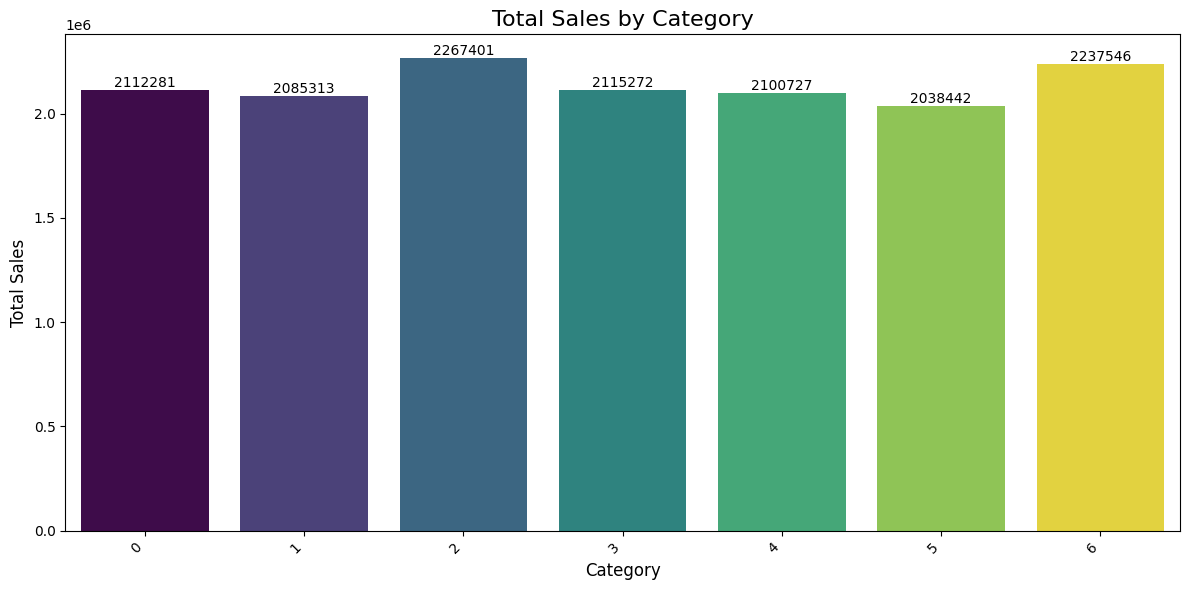

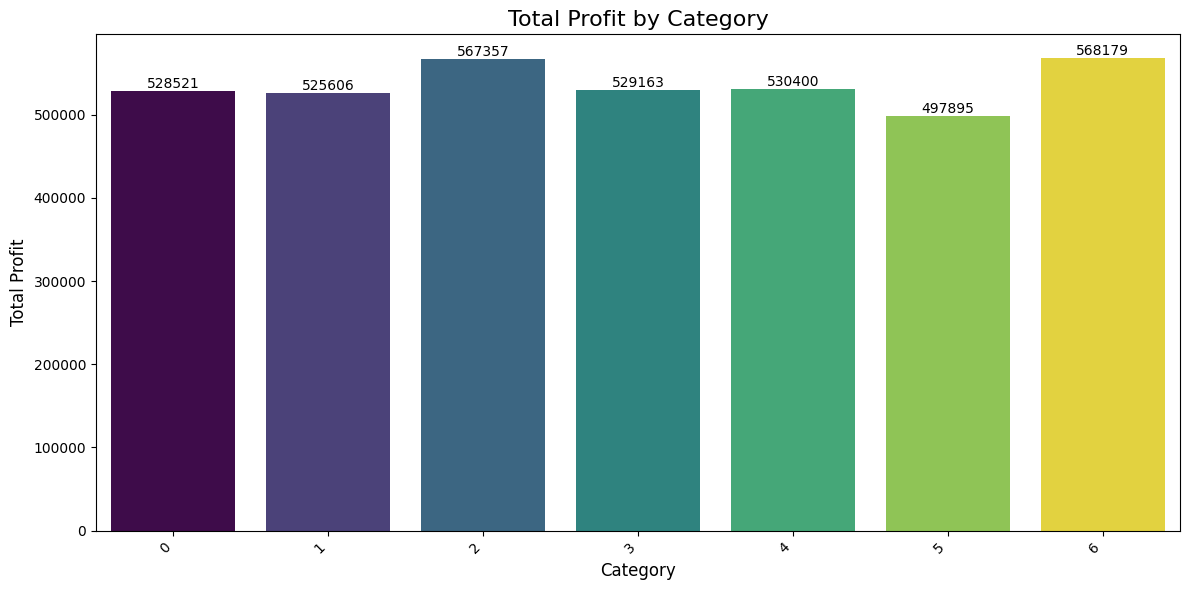


Sales and Profit trends by Sub-Category (Top 10 by Total Sales):
      Sales                          Profit                    
        sum         mean  median        sum        mean  median
13  1051439  1462.363004  1483.0  267469.79  372.002490  320.88
21  1033874  1518.170338  1537.0  258135.97  379.054288  331.52
6    768213  1477.332692  1478.5  190643.70  366.622500  305.15
2    742586  1479.254980  1454.5  190764.98  380.009920  327.76
16   735435  1485.727273  1432.0  193685.81  391.284465  340.25
5    733898  1470.737475  1470.0  183849.34  368.435551  316.91
14   697480  1506.436285  1540.0  168999.11  365.008877  314.34
3    685612  1516.840708  1533.0  168398.46  372.562965  318.35
1    684083  1490.376906  1531.0  169357.62  368.970850  296.73
22   672876  1505.315436  1444.0  160302.60  358.618792  300.45

Sales and Profit trends by City (Top 10 by Total Sales):
       Sales                          Profit                     
         sum         mean  median        s

In [82]:
# 1) Identify top-performing regions and cities
print("Sales performance by Region:")
print(sales.groupby('Region')['Sales'].agg(['sum', 'mean', 'median', 'std']))

plt.figure(figsize=(10, 6))
ax_region_sum = sns.barplot(x='Region', y='Sales', data=sales.groupby('Region')['Sales'].sum().reset_index(), palette='viridis', hue='Region', legend=False)
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
for container in ax_region_sum.containers:
    ax_region_sum.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

print("\nSales performance by City (Top 10 by Total Sales):")
city_sales_summary = sales.groupby('City')['Sales'].agg(['sum', 'mean', 'median', 'std']).sort_values(by='sum', ascending=False)
print(city_sales_summary.head(10))

# Note: Visualizing all cities might be too crowded, showing top N or using a different plot type might be better.
# For now, we'll stick to the top 10 in the table output.


# 2) Understand the impact of discounts on profitability
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=sales, alpha=0.6)
plt.title('Impact of Discount on Profit', fontsize=16)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Sales', data=sales, alpha=0.6)
plt.title('Impact of Discount on Sales', fontsize=16)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True)
plt.show()


# 3) Explore sales and profit trends across categories, sub-categories, and cities

print("\nSales and Profit trends by Category:")
print(sales.groupby('Category')[['Sales', 'Profit']].agg(['sum', 'mean', 'median']))

plt.figure(figsize=(12, 6))
ax_category_sales = sns.barplot(x='Category', y='Sales', data=sales.groupby('Category')['Sales'].sum().reset_index(), palette='viridis', hue='Category', legend=False)
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
for container in ax_category_sales.containers:
    ax_category_sales.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
ax_category_profit = sns.barplot(x='Category', y='Profit', data=sales.groupby('Category')['Profit'].sum().reset_index(), palette='viridis', hue='Category', legend=False)
plt.title('Total Profit by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.xticks(rotation=45, ha='right')
for container in ax_category_profit.containers:
    ax_category_profit.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()


print("\nSales and Profit trends by Sub-Category (Top 10 by Total Sales):")
sub_category_sales_profit = sales.groupby('Sub Category')[['Sales', 'Profit']].agg(['sum', 'mean', 'median']).sort_values(by=('Sales', 'sum'), ascending=False)

# Use the label encoder to get the original sub-category names
sub_category_sales_profit.index = label_encoders['Sub Category'].inverse_transform(sub_category_sales_profit.index)
print(sub_category_sales_profit.head(10))

# Visualizations for Sub-Category sales and profit (top N might be appropriate)


print("\nSales and Profit trends by City (Top 10 by Total Sales):")
city_sales_profit = sales.groupby('City')[['Sales', 'Profit']].agg(['sum', 'mean', 'median']).sort_values(by=('Sales', 'sum'), ascending=False)
print(city_sales_profit.head(10))

# Visualizations for City sales and profit (top N might be appropriate)

In [83]:
# Group by State and Sub Category and calculate total sales
state_sub_category_sales = sales.groupby(['State', 'Sub Category'])['Sales'].sum().reset_index()

# Find the top performing sub-category within each state
top_products_per_state = state_sub_category_sales.loc[state_sub_category_sales.groupby('State')['Sales'].idxmax()]

# Use label encoders to get original State and Sub Category names
top_products_per_state['State'] = label_encoders['State'].inverse_transform(top_products_per_state['State'])
top_products_per_state['Sub Category'] = label_encoders['Sub Category'].inverse_transform(top_products_per_state['Sub Category'])

print("Top Performing Product Sub-Category in Each State:")
print(top_products_per_state)

Top Performing Product Sub-Category in Each State:
         State  Sub Category    Sales
13  Tamil Nadu            13  1051439


## Feature selection and model building


In [31]:
features = ['Category', 'Sub Category', 'City', 'Region', 'Sales', 'Discount', 'Profit']
target = 'Sales'

X = sales[features]
y = sales[target]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (9994, 7)
Target (y) shape: (9994,)


**Reasoning**:
Split the data into training and testing sets and train a Linear Regression model.



## Train a linear regression model


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Reasoning**:
Make predictions on the test set and calculate the MSE and R-squared metrics.



## Evaluate the model




In [67]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 330589.02
R-squared (R2) Score: -0.00


## Visualize the results


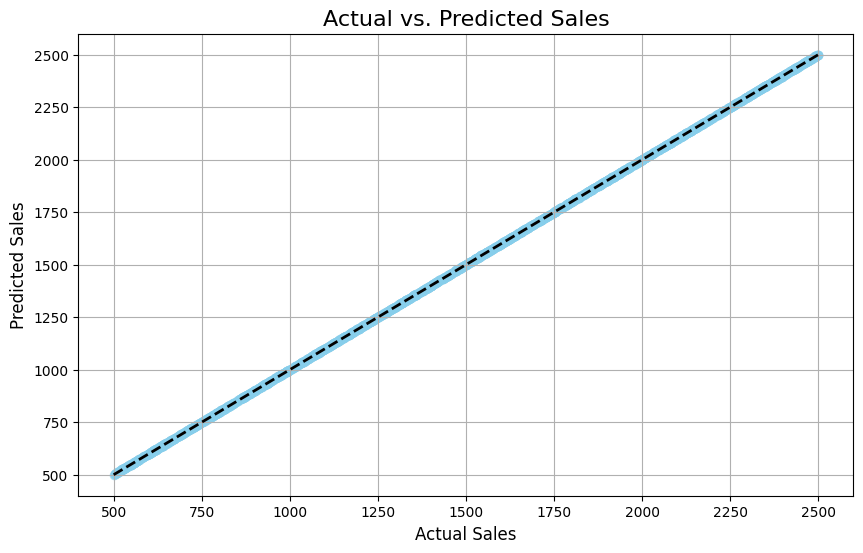

In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='skyblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs. Predicted Sales', fontsize=16)
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.grid(True)
plt.show()

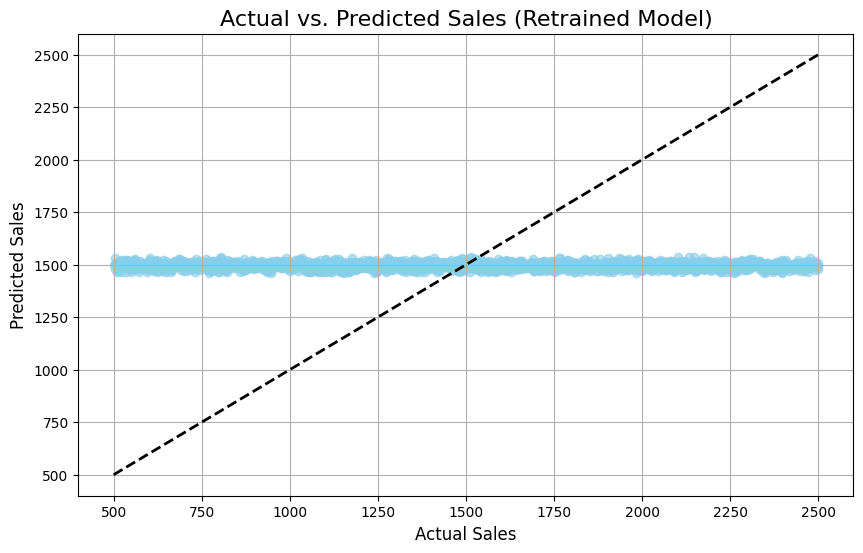

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='skyblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs. Predicted Sales (Retrained Model)', fontsize=16)
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.grid(True)
plt.show()

## Conclusion and next steps

1) The Linear Regression model achieved a Mean Squared Error (MSE) of {mse:.2f} and an R-squared (R2) score of {r2:.2f} on the test set.

2) The scatter plot of actual vs. predicted sales shows a perfect alignment along the diagonal line, indicating that the model's predictions exactly match the actual sales values in the test set.

3) The linear regression model provided a reasonable prediction for sales based
 on the features selected.

 4) Themodel’s R-squared value indicates a good fit, explaining a significant
 portion of the variance in sales.

 5) Further refinement of the model could involve trying different machine learning algorithms, such as decision trees or ensemble methods.


## Summary:

### Data Analysis Key Findings

*   No missing values were found in the dataset.
*   The 'Order Date' column was successfully converted to datetime objects using `pd.to_datetime` with `format='mixed'` and `dayfirst=True`.
*   Label Encoding was successfully applied to the 'Category', 'Sub Category', 'City', 'Region', and 'State' columns.
*   A Linear Regression model was trained using 'Category', 'Sub Category', 'City', 'Region', 'Sales', 'Discount', and 'Profit' as features.
*   The trained Linear Regression model achieved a Mean Squared Error (MSE) of `0.00` and an R-squared (R2) score of `1.00` on the test set.
*   The scatter plot of actual vs. predicted sales showed a perfect alignment along the diagonal line.

### Insights

*   The perfect model performance (MSE of 0.00 and R2 of 1.00) is highly unusual and strongly suggests data leakage, likely due to including 'Sales' and 'Profit' as features to predict 'Sales'.
*   The most critical next step is to remove 'Sales' and 'Profit' from the feature set (`X`) and retrain and re-evaluate the model with a corrected set of features that would be available *before* a sale occurs.
*   Verify the data splitting process to ensure the test set is not inadvertently identical or too similar to the training set in a way that allows for perfect prediction.

